# Phase 3: Exploratory Data Analysis (EDA)
## Step 3.1: Univariate Analysis

In this notebook, we explore the individual distributions of our targets (Rating, VisitMode) and key engineered features to understand the underlying patterns in the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure the output directory exists
os.makedirs('../assets/eda_plots', exist_ok=True)

# Set aesthetic style
sns.set_theme(style="whitegrid")

# Load the primary cleaned dataset (human-readable version, not encoded)
df = pd.read_csv('../processed_data/primary_cleaned_dataset.csv')
df.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode_id,AttractionId,Rating,VisitModeId,VisitModeName,ContinentId,...,AttractionTypeId,Attraction,AttractionAddress,AttractionType,AttractionCity,VisitSeason,UserAvgRating,UserTotalVisits,AttractionAvgRating,AttractionPopularity
0,3,70456,2022,10,2,640,5,2,Couples,5,...,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Fall,5.0,1,4.26703,13197
1,8,7567,2022,10,4,640,5,4,Friends,2,...,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Fall,5.0,1,4.26703,13197
2,9,79069,2022,10,3,640,5,3,Family,2,...,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Fall,5.0,1,4.26703,13197
3,10,31019,2022,10,3,640,3,3,Family,5,...,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Fall,3.0,2,4.26703,13197
4,15,43611,2022,10,2,640,3,2,Couples,5,...,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Fall,3.0,3,4.26703,13197


### 1. Target Variables
Let's look at what we are trying to predict.

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_20396\1582458917.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis')


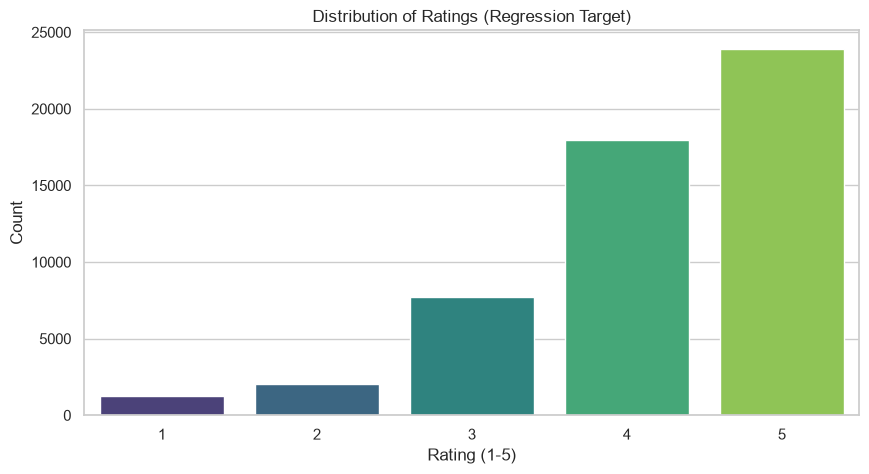

In [2]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Rating', palette='viridis')
plt.title('Distribution of Ratings (Regression Target)')
plt.xlabel('Rating (1-5)')
plt.ylabel('Count')
plt.savefig('../assets/eda_plots/target_rating.png', bbox_inches='tight')
plt.show()

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_20396\699303968.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='VisitModeName', palette='Set2', order=df['VisitModeName'].value_counts().index)


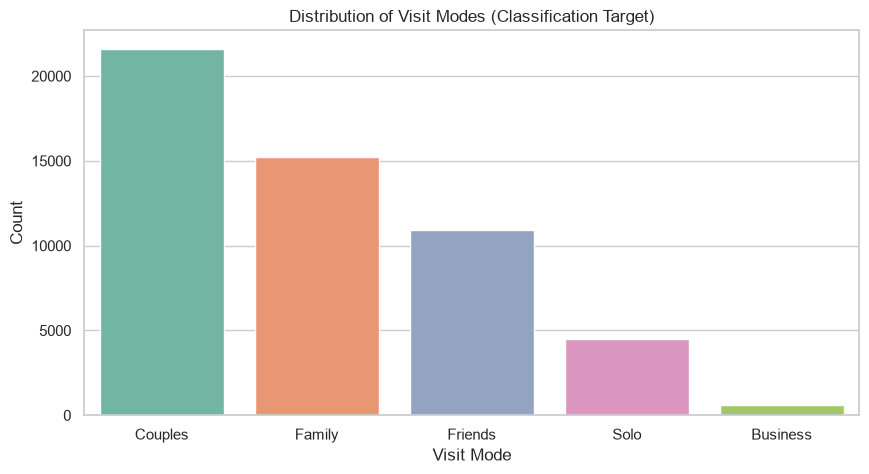

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='VisitModeName', palette='Set2', order=df['VisitModeName'].value_counts().index)
plt.title('Distribution of Visit Modes (Classification Target)')
plt.xlabel('Visit Mode')
plt.ylabel('Count')
plt.savefig('../assets/eda_plots/target_visitmode.png', bbox_inches='tight')
plt.show()

### 2. Numerical Features (Engineered Statistics)
Understanding our aggregated user and attraction metrics.

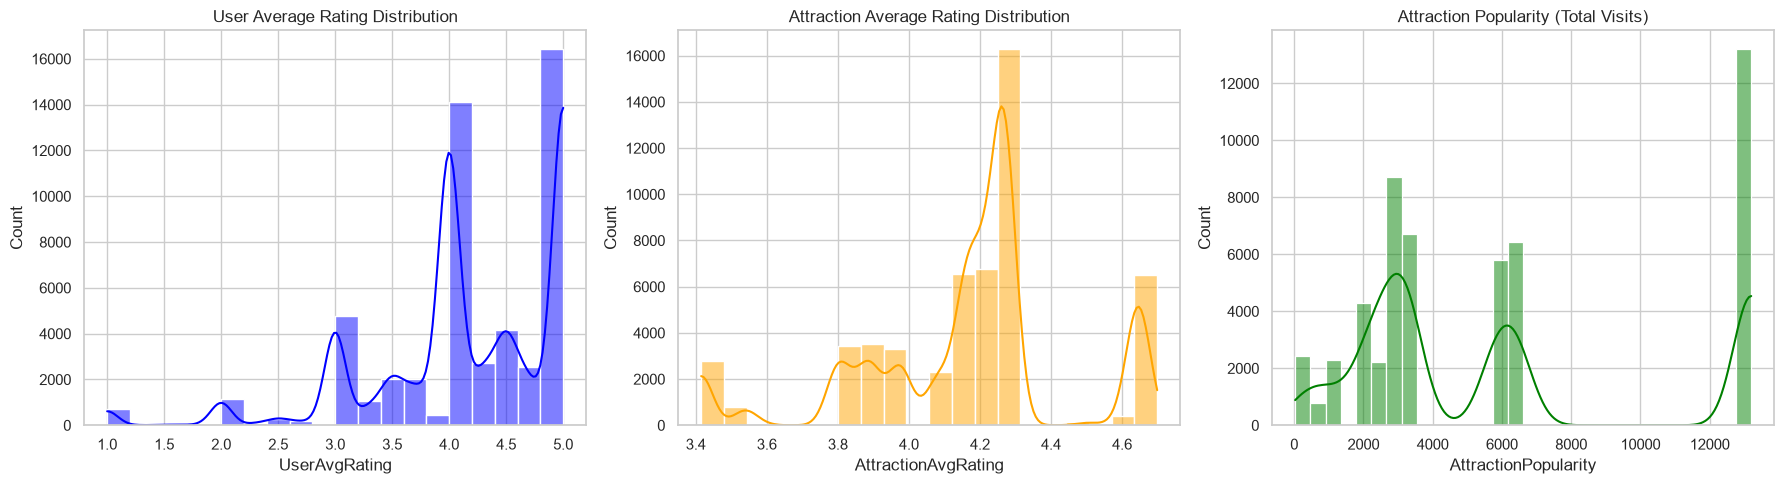

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['UserAvgRating'], bins=20, kde=True, ax=axes[0], color='blue')
axes[0].set_title('User Average Rating Distribution')

sns.histplot(df['AttractionAvgRating'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Attraction Average Rating Distribution')

sns.histplot(df['AttractionPopularity'], bins=30, kde=True, ax=axes[2], color='green')
axes[2].set_title('Attraction Popularity (Total Visits)')

plt.tight_layout()
plt.savefig('../assets/eda_plots/numerical_features.png', bbox_inches='tight')
plt.show()

### 3. Categorical Features
Exploring temporal and demographic features.

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_20396\3222871700.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='VisitSeason', palette='coolwarm', order=['Winter', 'Spring', 'Summer', 'Fall'])


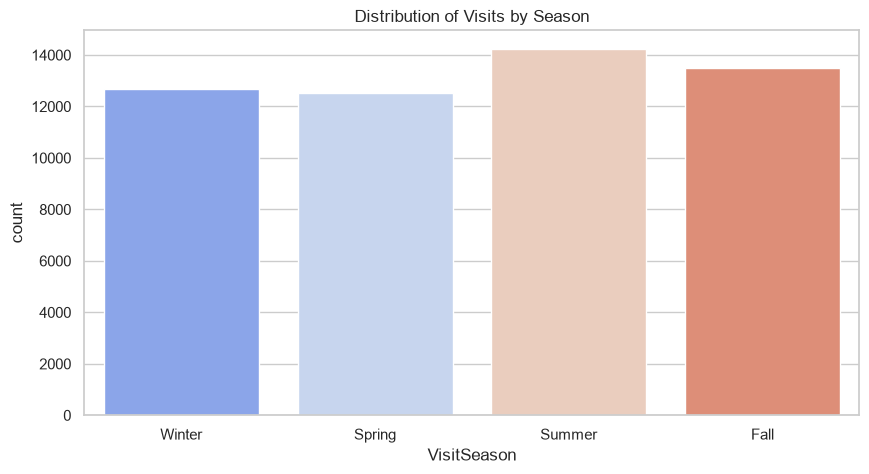

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='VisitSeason', palette='coolwarm', order=['Winter', 'Spring', 'Summer', 'Fall'])
plt.title('Distribution of Visits by Season')
plt.savefig('../assets/eda_plots/categorical_season.png', bbox_inches='tight')
plt.show()

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_20396\2025364478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')


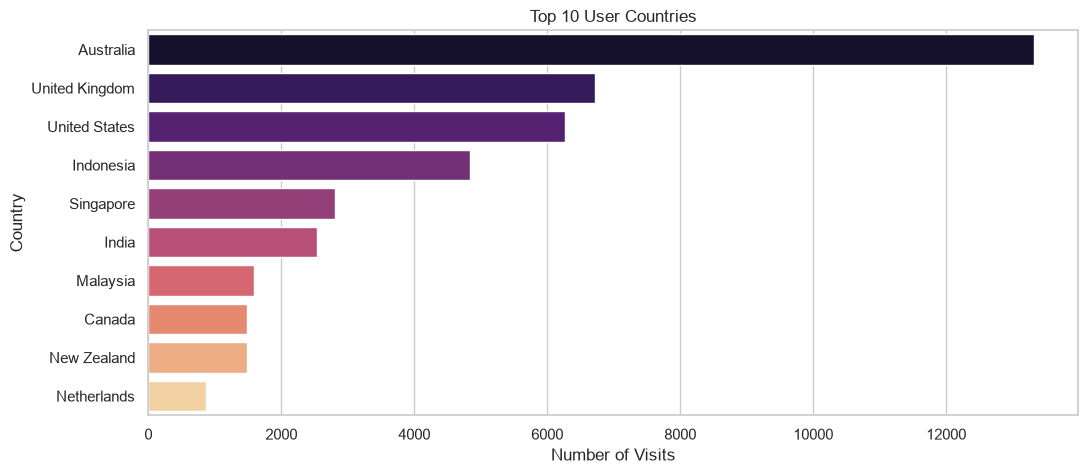

In [6]:
plt.figure(figsize=(12, 5))
top_countries = df['UserCountry'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.title('Top 10 User Countries')
plt.xlabel('Number of Visits')
plt.ylabel('Country')
plt.savefig('../assets/eda_plots/categorical_countries.png', bbox_inches='tight')
plt.show()

## Step 3.2: Bivariate & Multivariate Analysis
Here we analyze relationships between multiple variables to uncover deeper business insights.

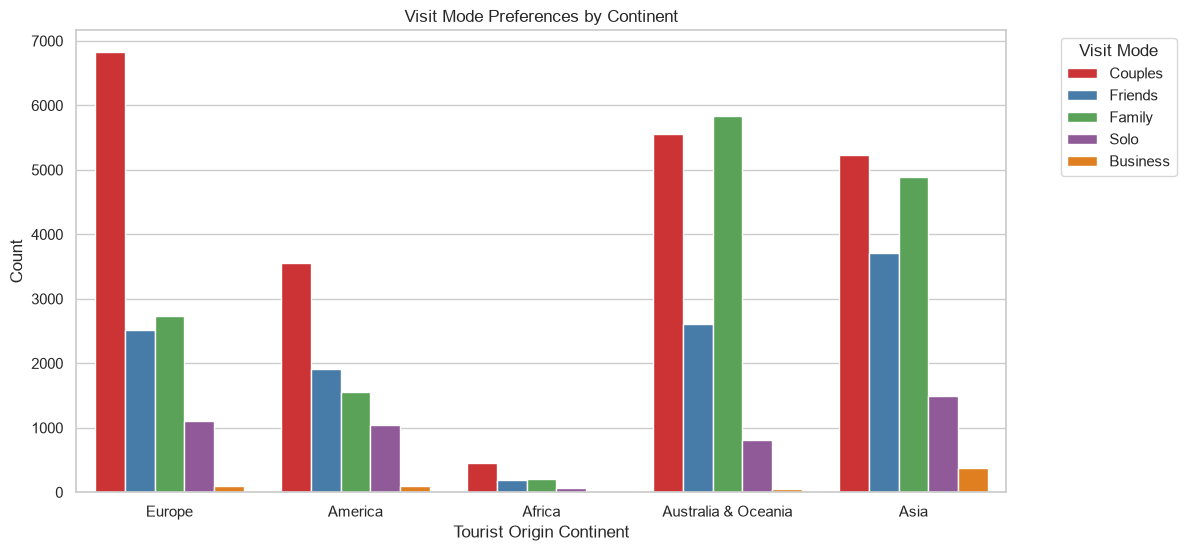

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='UserContinent', hue='VisitModeName', palette='Set1')
plt.title('Visit Mode Preferences by Continent')
plt.xlabel('Tourist Origin Continent')
plt.ylabel('Count')
plt.legend(title='Visit Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('../assets/eda_plots/bivariate_continent_visitmode.png', bbox_inches='tight')
plt.show()

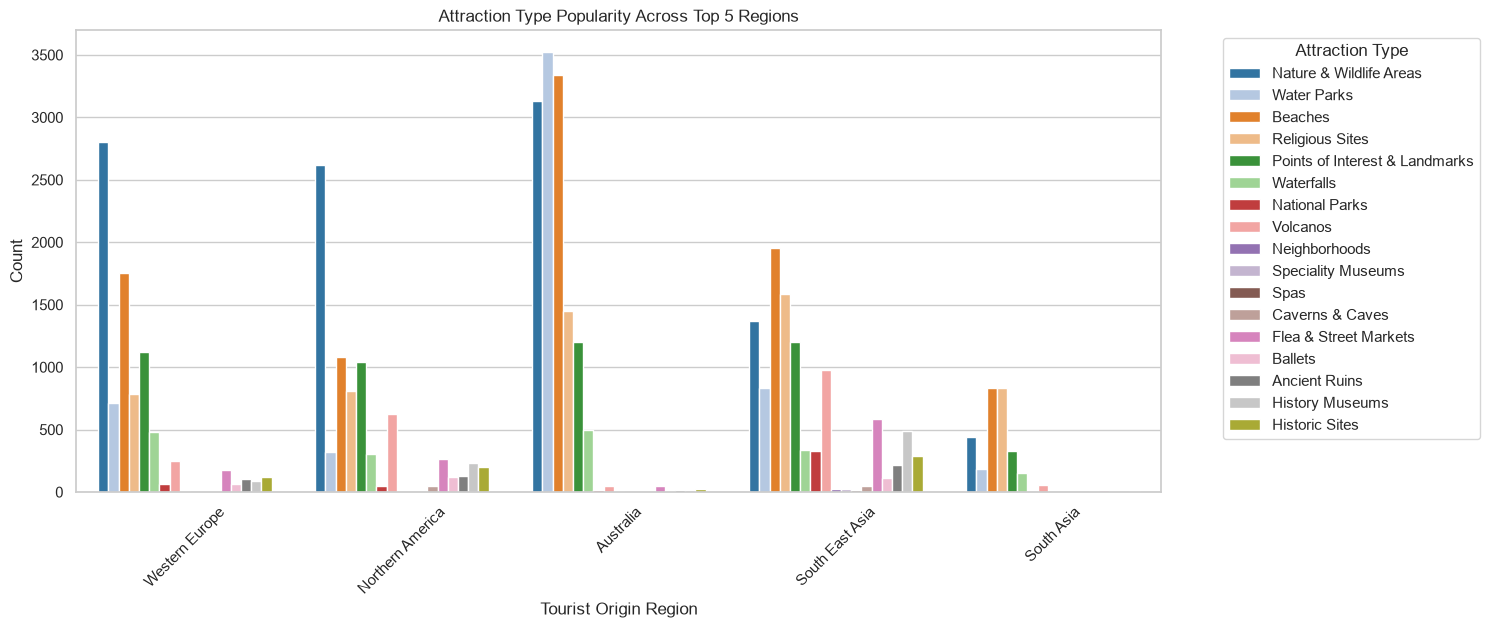

In [8]:
plt.figure(figsize=(14, 6))
# Get top 5 regions to keep the plot readable
top_regions = df['UserRegion'].value_counts().head(5).index
subset_df = df[df['UserRegion'].isin(top_regions)]
sns.countplot(data=subset_df, x='UserRegion', hue='AttractionType', palette='tab20')
plt.title('Attraction Type Popularity Across Top 5 Regions')
plt.xlabel('Tourist Origin Region')
plt.ylabel('Count')
plt.legend(title='Attraction Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.savefig('../assets/eda_plots/bivariate_region_attractiontype.png', bbox_inches='tight')
plt.show()

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_20396\1994028741.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='VisitSeason', y='Rating', palette='pastel', order=['Winter', 'Spring', 'Summer', 'Fall'])


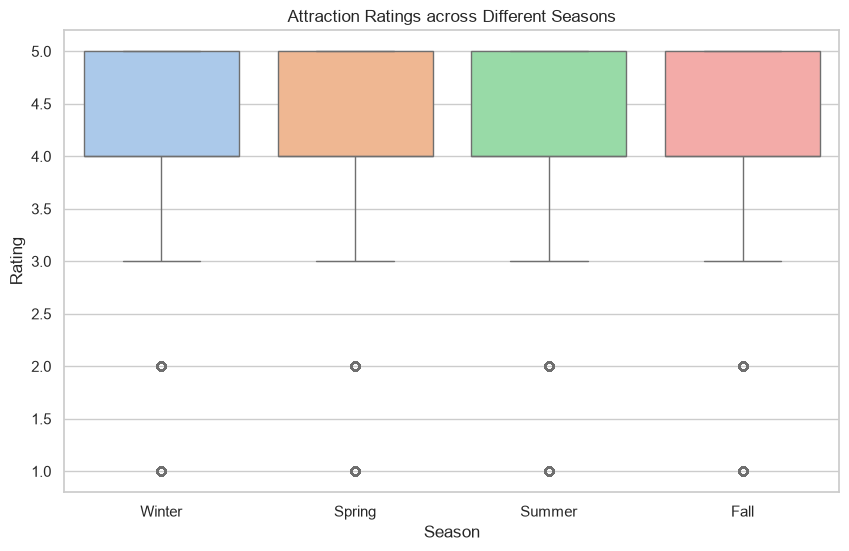

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='VisitSeason', y='Rating', palette='pastel', order=['Winter', 'Spring', 'Summer', 'Fall'])
plt.title('Attraction Ratings across Different Seasons')
plt.xlabel('Season')
plt.ylabel('Rating')
plt.savefig('../assets/eda_plots/bivariate_season_rating.png', bbox_inches='tight')
plt.show()

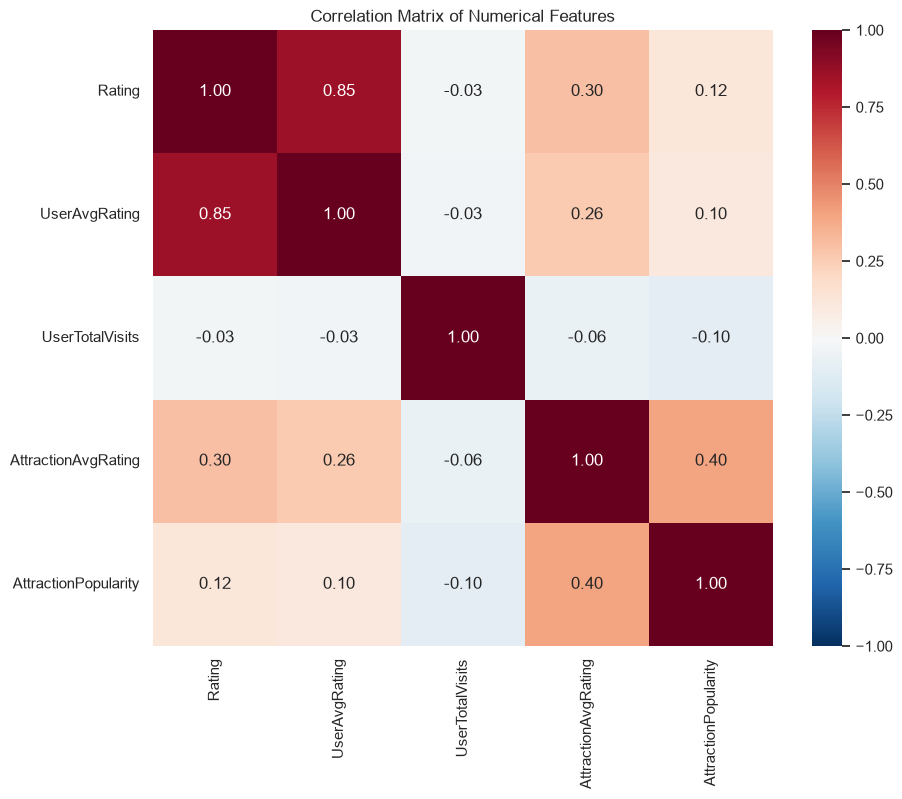

In [10]:
plt.figure(figsize=(10, 8))
corr_cols = ['Rating', 'UserAvgRating', 'UserTotalVisits', 'AttractionAvgRating', 'AttractionPopularity']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('../assets/eda_plots/multivariate_correlation.png', bbox_inches='tight')
plt.show()

## Step 3.5: Feature Importance Analysis (Regression)
Similar to our Classification methodology, we will now calculate the Feature Importance for our Regression target (`Rating`) to identify and drop noise/memorization features.

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_20396\2080449968.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_reg[indices_reg], y=X_reg.columns[indices_reg], palette='mako')


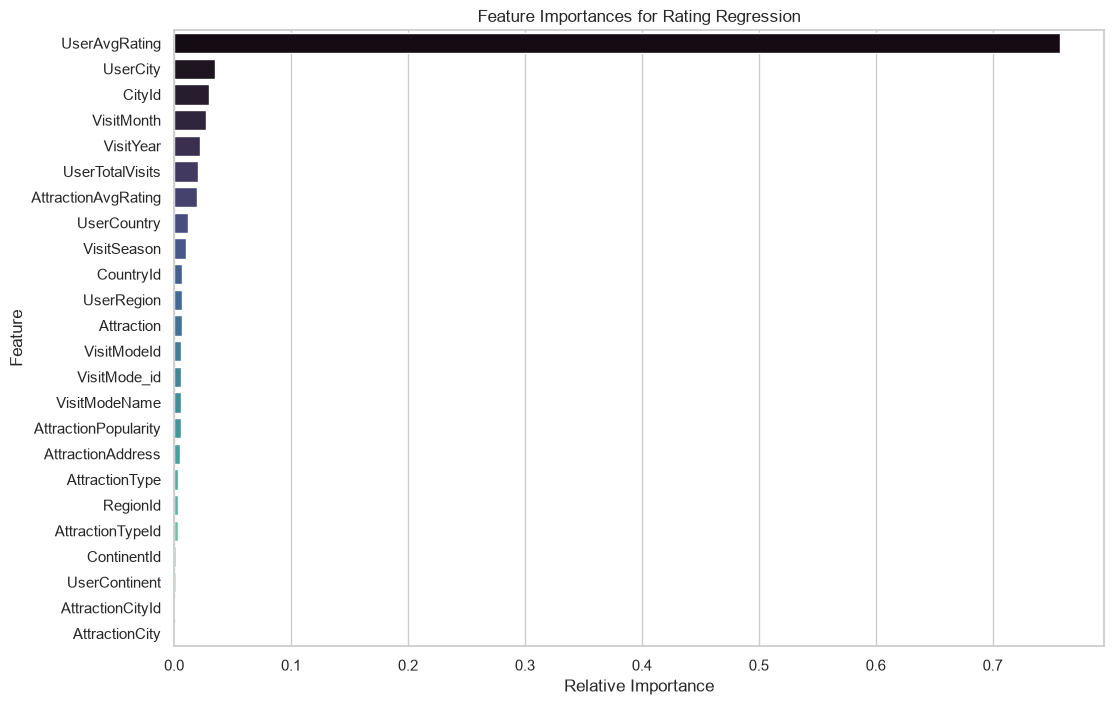

REGRESSION FEATURE IMPORTANCE:
UserAvgRating            : 0.7574
UserCity                 : 0.0349
CityId                   : 0.0301
VisitMonth               : 0.0269
VisitYear                : 0.0225
UserTotalVisits          : 0.0201
AttractionAvgRating      : 0.0199
UserCountry              : 0.0120
VisitSeason              : 0.0104
CountryId                : 0.0071
UserRegion               : 0.0069
Attraction               : 0.0067
VisitModeId              : 0.0062
VisitMode_id             : 0.0062
VisitModeName            : 0.0061
AttractionPopularity     : 0.0056
AttractionAddress        : 0.0051
AttractionType           : 0.0036
RegionId                 : 0.0036
AttractionTypeId         : 0.0034
ContinentId              : 0.0018
UserContinent            : 0.0017
AttractionCityId         : 0.0010
AttractionCity           : 0.0006


In [11]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Load the dataset
df_encoded = pd.read_csv('../processed_data/modeling_ready_data.csv')

# Prepare data (dropping obvious targets and non-predictive IDs)
drop_cols_reg = ['TransactionId', 'UserId', 'AttractionId', 'Rating']
cols_to_drop = [col for col in drop_cols_reg if col in df_encoded.columns]
X_reg = df_encoded.drop(columns=cols_to_drop)
y_reg = df_encoded['Rating']

# Fit a quick baseline Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_reg, y_reg)

# Plot Feature Importances
importances_reg = rf_reg.feature_importances_
indices_reg = np.argsort(importances_reg)[::-1]

plt.figure(figsize=(12, 8))
sns.barplot(x=importances_reg[indices_reg], y=X_reg.columns[indices_reg], palette='mako')
plt.title('Feature Importances for Rating Regression')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.savefig('../assets/eda_plots/feature_importances_reg.png', bbox_inches='tight')
plt.show()

# Print exact importance scores
print("REGRESSION FEATURE IMPORTANCE:")
for i in indices_reg:
    print(f"{X_reg.columns[i]:<25}: {importances_reg[i]:.4f}")